In [1]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [82]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve,
    auc
)
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error
)
from scipy.stats import (
    pearsonr,
    norm
)

---
# Get Data

In [3]:
# Get local data

utmb_race_results_df_list = []
for year in [2022, 2023, 2024, 2025]:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_list.append(utmb_year_race_results_df)

utmb_race_results_df = pd.concat(utmb_race_results_df_list, ignore_index=True)

Data for year 2022 fetched and loaded successfully
Data for year 2023 fetched and loaded successfully
Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [4]:
# About

print("About UTMB race results data:")
print("----------------------------------")

print("Years covered: {}".format(utmb_race_results_df["year"].unique()))
print("Number of records per year:")
for row in utmb_race_results_df["year"].value_counts().reset_index().itertuples():
    print(" - {}: {:,}".format(row[1], row[2]))

print("\nMissing data:")
for column in utmb_race_results_df.columns:
    missing_count = utmb_race_results_df[column].isnull().sum()
    if missing_count > 0:
        print(" - {}: {:,} ({:.2f}%)".format(column, missing_count, missing_count/utmb_race_results_df.shape[0] * 100))

About UTMB race results data:
----------------------------------
Years covered: [2022 2023 2024 2025]
Number of records per year:
 - 2024: 2,760
 - 2023: 2,687
 - 2022: 2,627
 - 2025: 2,489

Missing data:
 - race_category: 5,314 (50.31%)
 - runner_url: 5 (0.05%)
 - runner_overall_index: 199 (1.88%)
 - runner_diff_to_first_time: 3,592 (34.01%)
 - runner_diff_to_first_time_hours: 3,592 (34.01%)
 - race_start_time_hours: 10,563 (100.00%)
 - runner_final_status_map: 1 (0.01%)


---
# Research
What is the minimum UTMB Index such that I finish under 27h with 95% confidence?
1. Probability of finishing the race.
2. Conditional probability of finishing under 27 hours given race completion.

Clean data

In [9]:
# Keep only necessary columns
df = utmb_race_results_df[[
    "runner_overall_index", "runner_race_time_hours", "runner_final_status_map",  "runner_is_finisher"
]].copy()

In [10]:
# Convert race time of DNF runners to NaN, so we do not confuse later ...
df = df.assign(
    runner_race_time_hours = lambda df: np.where(df["runner_is_finisher"] == False, np.nan, df["runner_race_time_hours"])
)

# Check
assert df.query("runner_is_finisher == False")["runner_race_time_hours"].isnull().all()

In [14]:
# Keep two separate dataframes - Full ~ Explore finishers, Finisher ~ Explore race time
df_full = df.copy()
df_finisher = df.query("runner_is_finisher == True").reset_index(drop=True).copy()

About - EDA

In [16]:
# Printouts

# Probability of finishing ~ UTMB index
print(" - Finishing rate: {:.2f}%".format(df_full["runner_is_finisher"].mean() * 100))
print("     - Average UMTB index of finishers: {:.0f}".format(df_finisher["runner_overall_index"].mean()))
print("     - Average UMTB index of non finishers: {:.0f}".format(df_full.query("runner_is_finisher == 0")["runner_overall_index"].mean()))

# Race Time ~ UTMB index | Finisher
print("\n - Average race time of finishers: {:.2f} hours".format(df_finisher["runner_race_time_hours"].mean()))
print(" - Proportion of finishers under 27h: {:.2f}%".format((df_finisher["runner_race_time_hours"] <= 27).mean() * 100))
print("     -  UTMB index of finishers under 27h: average = {:.0f}, lowest = {:.0f}".format(
    df_finisher.query("runner_race_time_hours <= 27")["runner_overall_index"].mean(), 
    df_finisher.query("runner_race_time_hours <= 27")["runner_overall_index"].min())
)
print("     -  UTMB index of finishers over 27h: average = {:.0f}, lowest = {:.0f}, highest = {:.0f}".format(
    df_finisher.query("runner_race_time_hours > 27")["runner_overall_index"].mean(), 
    df_finisher.query("runner_race_time_hours > 27")["runner_overall_index"].min(),
    df_finisher.query("runner_race_time_hours > 27")["runner_overall_index"].max()
))

 - Finishing rate: 65.99%
     - Average UMTB index of finishers: 571
     - Average UMTB index of non finishers: 542

 - Average race time of finishers: 39.11 hours
 - Proportion of finishers under 27h: 4.56%
     -  UTMB index of finishers under 27h: average = 803, lowest = 667
     -  UTMB index of finishers over 27h: average = 559, lowest = 334, highest = 884


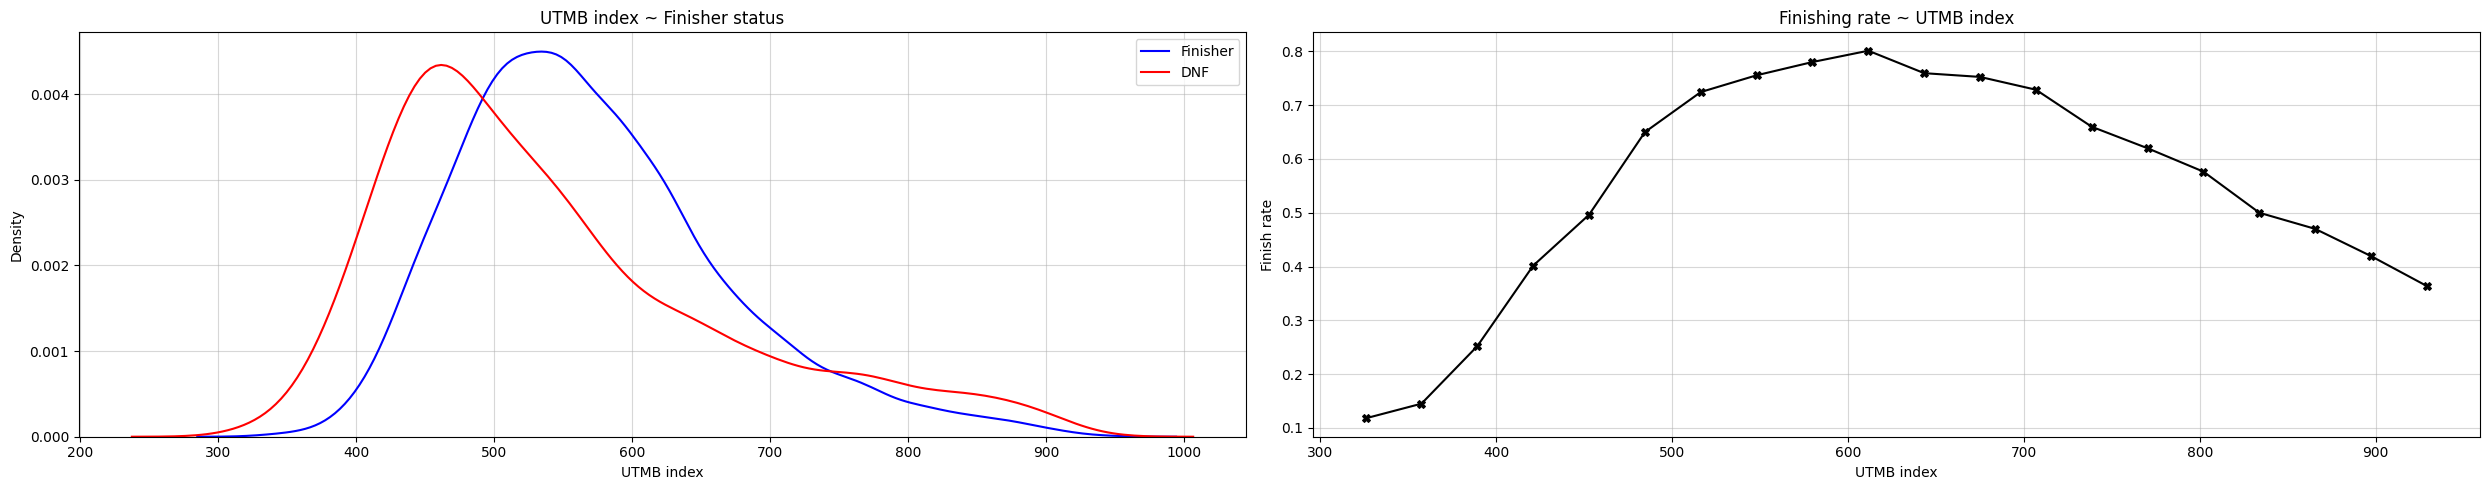

In [50]:
# Plots - Finishing rate ~ UTMB index

fig, ax = plt.subplots(1,2, figsize=(25, 5)) 

# UTMB index distribution ~ Finisher status
ax[0].set_title("UTMB index ~ Finisher status")
sns.kdeplot(
    df_full.query("runner_is_finisher == @True")["runner_overall_index"],
    color="blue", label="Finisher", ax=ax[0]
)
sns.kdeplot(
    df_full.query("runner_is_finisher == @False")["runner_overall_index"],
    color="red", label="DNF", ax=ax[0]
)
ax[0].set_ylabel("Density")
ax[0].legend()

# Finish probability ~ UTMB index
bin_edges = np.linspace(
    df_full["runner_overall_index"].min(),
    df_full["runner_overall_index"].max(),
    21
)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

finish_rate_agg = (
    df_full
    .assign(
        runner_overall_index_binned = pd.cut(
            df_full["runner_overall_index"],
            bins=bin_edges,
            labels=bin_centers
        ).astype(float)
    )
    .groupby("runner_overall_index_binned")
    .agg(
        average_finish_rate=("runner_is_finisher", "mean"),
        sample_size=("runner_is_finisher", "count")
    )
    .reset_index()
)

ax[1].set_title("Finishing rate ~ UTMB index")
sns.lineplot(
    x=finish_rate_agg["runner_overall_index_binned"], y=finish_rate_agg["average_finish_rate"], 
    marker="X", color="black", markeredgecolor="black", ax=ax[1]
)
ax[1].set_ylabel("Finish rate")

for i in range(2):
    ax[i].set_xlabel("UTMB index")
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

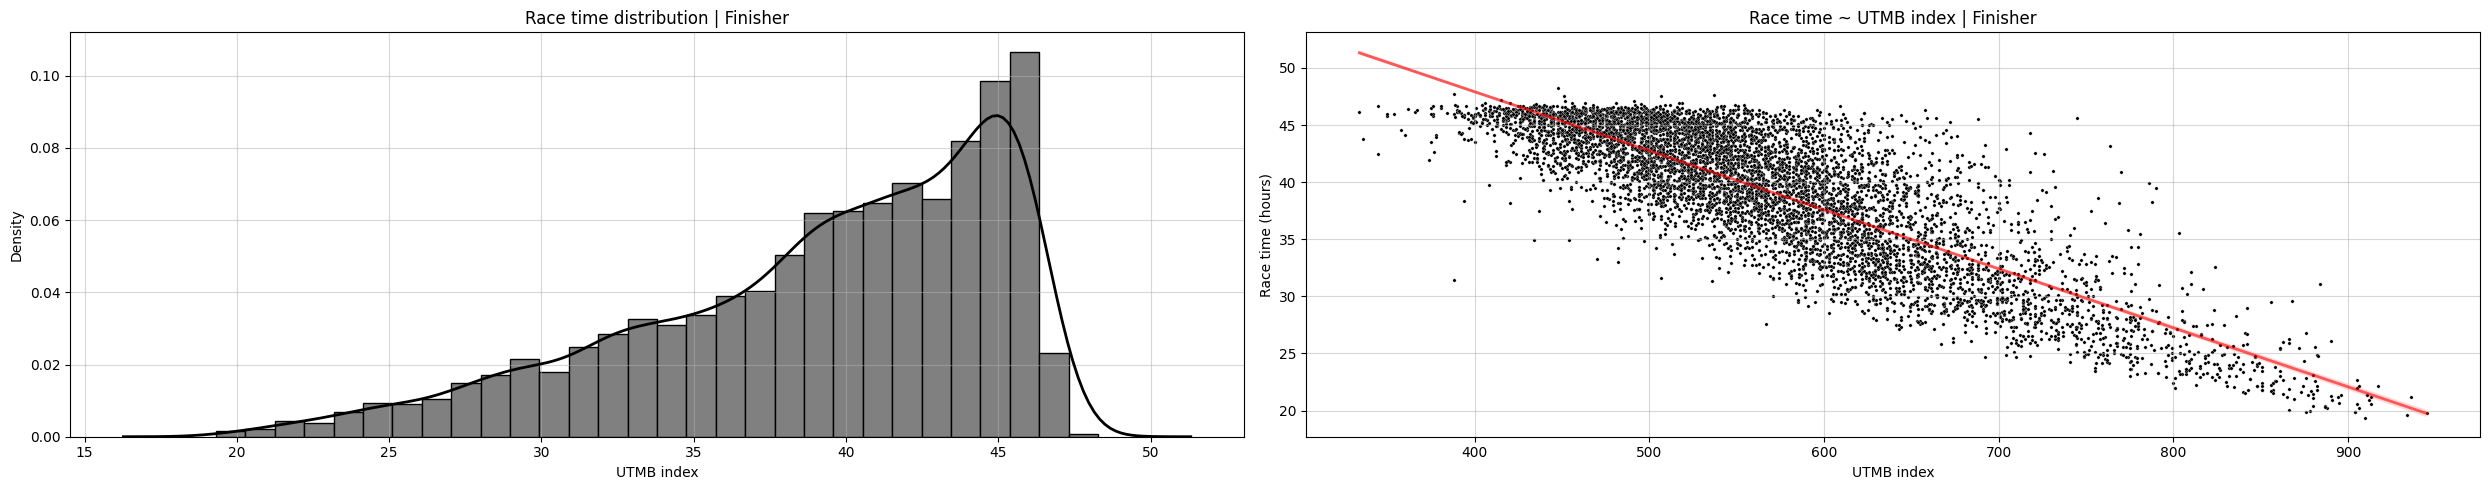

In [66]:
# Plots - Race time ~ UTMB index

fig, ax = plt.subplots(1,2, figsize=(25, 5))

# Race time distribution | Finisher
ax[0].set_title("Race time distribution | Finisher")
ax[0].hist(df_finisher["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(df_finisher["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Race time (hours)")

# Race time ~ UTMB index | Finisher
ax[1].set_title("Race time ~ UTMB index | Finisher")
sns.scatterplot(
    x=df_finisher["runner_overall_index"], y=df_finisher["runner_race_time_hours"],
    color="black", s=6, alpha=1.0, ax=ax[1]  
)
sns.regplot(
    x=df_finisher["runner_overall_index"], y=df_finisher["runner_race_time_hours"],
    scatter=False, line_kws={"color": "red", "linewidth": 2, "alpha": .6}, ax=ax[1]    
)
ax[1].set_ylabel("Race time (hours)")


for i in range(2):
    ax[i].set_xlabel("UTMB index")
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

---
### Probability of Finishing ~ UTMB index | Logistic regression

Fit & Diagnostic

In [91]:
# Fit & Predict on train data

# Prepare for model
target_logit = "runner_is_finisher"
features_logit = ["runner_overall_index"]
data_logit = df_full.copy()

data_model_logit = data_logit[[target_logit] + features_logit].dropna(how="any").reset_index(drop=True)
X_logit = sm.add_constant(data_model_logit[features_logit])
y_logit = data_model_logit[target_logit]

# Fit
model_logit = sm.Logit(y_logit, X_logit)
fit_logit = model_logit.fit(disp=False)

# Predict on train data
y_pred_logit = fit_logit.predict(X_logit)
fit_summary_logit = fit_logit.get_prediction(X_logit)

# Prepare data
df_logit = data_model_logit.assign(
    y_pred_logit = y_pred_logit
)

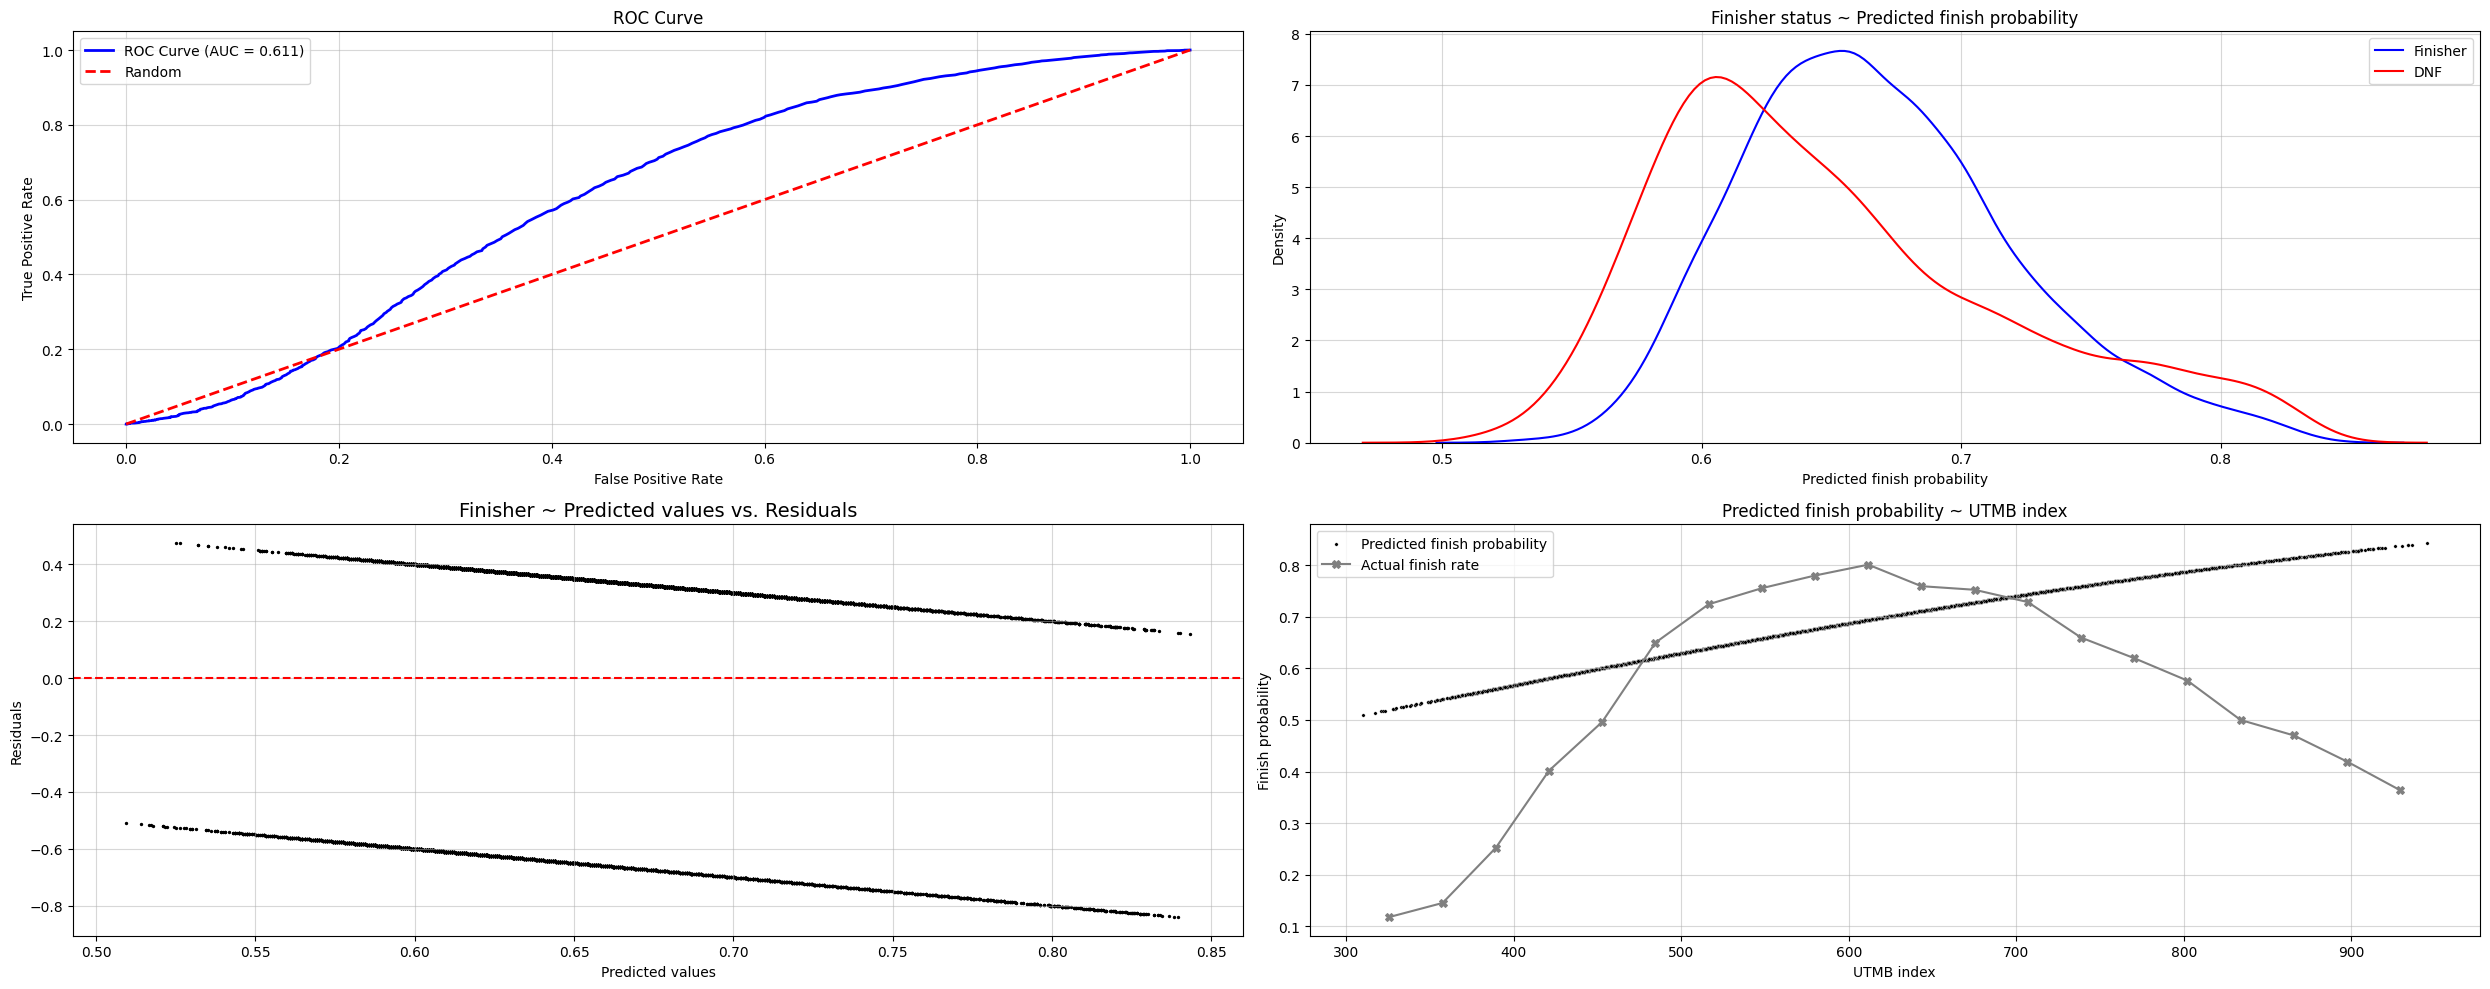

In [ ]:
# Model diagnostic

residuals_logit = y_logit - y_pred_logit
fig, ax = plt.subplots(2,2, figsize=(25, 10))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_logit, y_pred_logit)
roc_auc = auc(fpr, tpr)
ax[0,0].set_title("ROC Curve")
ax[0,0].plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
ax[0,0].plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random")
ax[0,0].set_xlabel("False Positive Rate")
ax[0,0].set_ylabel("True Positive Rate")
ax[0,0].legend()

# Finisher status ~ Predicted finish probability
ax[0,1].set_title("Finisher status ~ Predicted finish probability")
sns.kdeplot(
    df_logit.query("runner_is_finisher == @True")["y_pred_logit"],
    color="blue", label="Finisher", ax=ax[0,1]
)
sns.kdeplot(
    df_logit.query("runner_is_finisher == @False")["y_pred_logit"],
    color="red", label="DNF", ax=ax[0,1]
)
ax[0,1].set_xlabel("Predicted finish probability")
ax[0,1].set_ylabel("Density")
ax[0,1].legend()

# Residuals Homoskedasticity
ax[1,0].set_title("Finisher ~ Predicted values vs. Residuals", fontsize=14)
ax[1,0].scatter(y_pred_logit, residuals_logit, color="black", s=2)
ax[1,0].axhline(0, color="red", linestyle="--")
ax[1,0].set_xlabel(f"Predicted values")
ax[1,0].set_ylabel("Residuals")

# Predicted finish probability ~ UTMB index
bin_edges = np.linspace(
    df_logit["runner_overall_index"].min(),
    df_logit["runner_overall_index"].max(),
    21
)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

finish_rate_agg = (
    df_logit
    .assign(
        runner_overall_index_binned = pd.cut(
            df_logit["runner_overall_index"],
            bins=bin_edges,
            labels=bin_centers
        ).astype(float)
    )
    .groupby("runner_overall_index_binned")
    .agg(
        average_finish_rate=("runner_is_finisher", "mean"),
        sample_size=("runner_is_finisher", "count")
    )
    .reset_index()
)

ax[1,1].set_title("Predicted finish probability ~ UTMB index")
sns.scatterplot(
    x=df_logit["runner_overall_index"], y=df_logit["y_pred_logit"], label="Predicted finish probability",
    color="black", s=6, alpha=1.0, ax=ax[1,1]  
)
sns.lineplot(
    x=finish_rate_agg["runner_overall_index_binned"], y=finish_rate_agg["average_finish_rate"], label="Actual finish rate",
    marker="X", color="grey", markeredgecolor="grey", ax=ax[1,1]
)
ax[1,1].set_xlabel("UTMB index")
ax[1,1].set_ylabel("Finish probability")


for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(alpha=.5)

plt.tight_layout()
plt.show()

---
### Race time ~ UTMB index | Finisher | Linear regression

Fit & Diagnostic

In [92]:
# Fit & Predict on train data

# Prepare for model
target_ols = "runner_race_time_hours"
features_ols = ["runner_overall_index"]
data_ols = df_finisher.copy()

data_model_ols = data_ols[[target_ols] + features_ols].dropna(how="any").reset_index(drop=True)
X_ols = sm.add_constant(data_model_ols[features_ols])
y_ols = data_model_ols[target_ols]

# Model & Predict
model_ols = sm.OLS(y_ols, X_ols)
fit_ols = model_ols.fit()

# Predict on train data
y_pred_ols = fit_ols.predict(X_ols)
fit_summary_ols = fit_ols.get_prediction(X_ols)

# Prepare data
df_ols = data_model_ols.assign(
    y_pred_ols = y_pred_ols
)

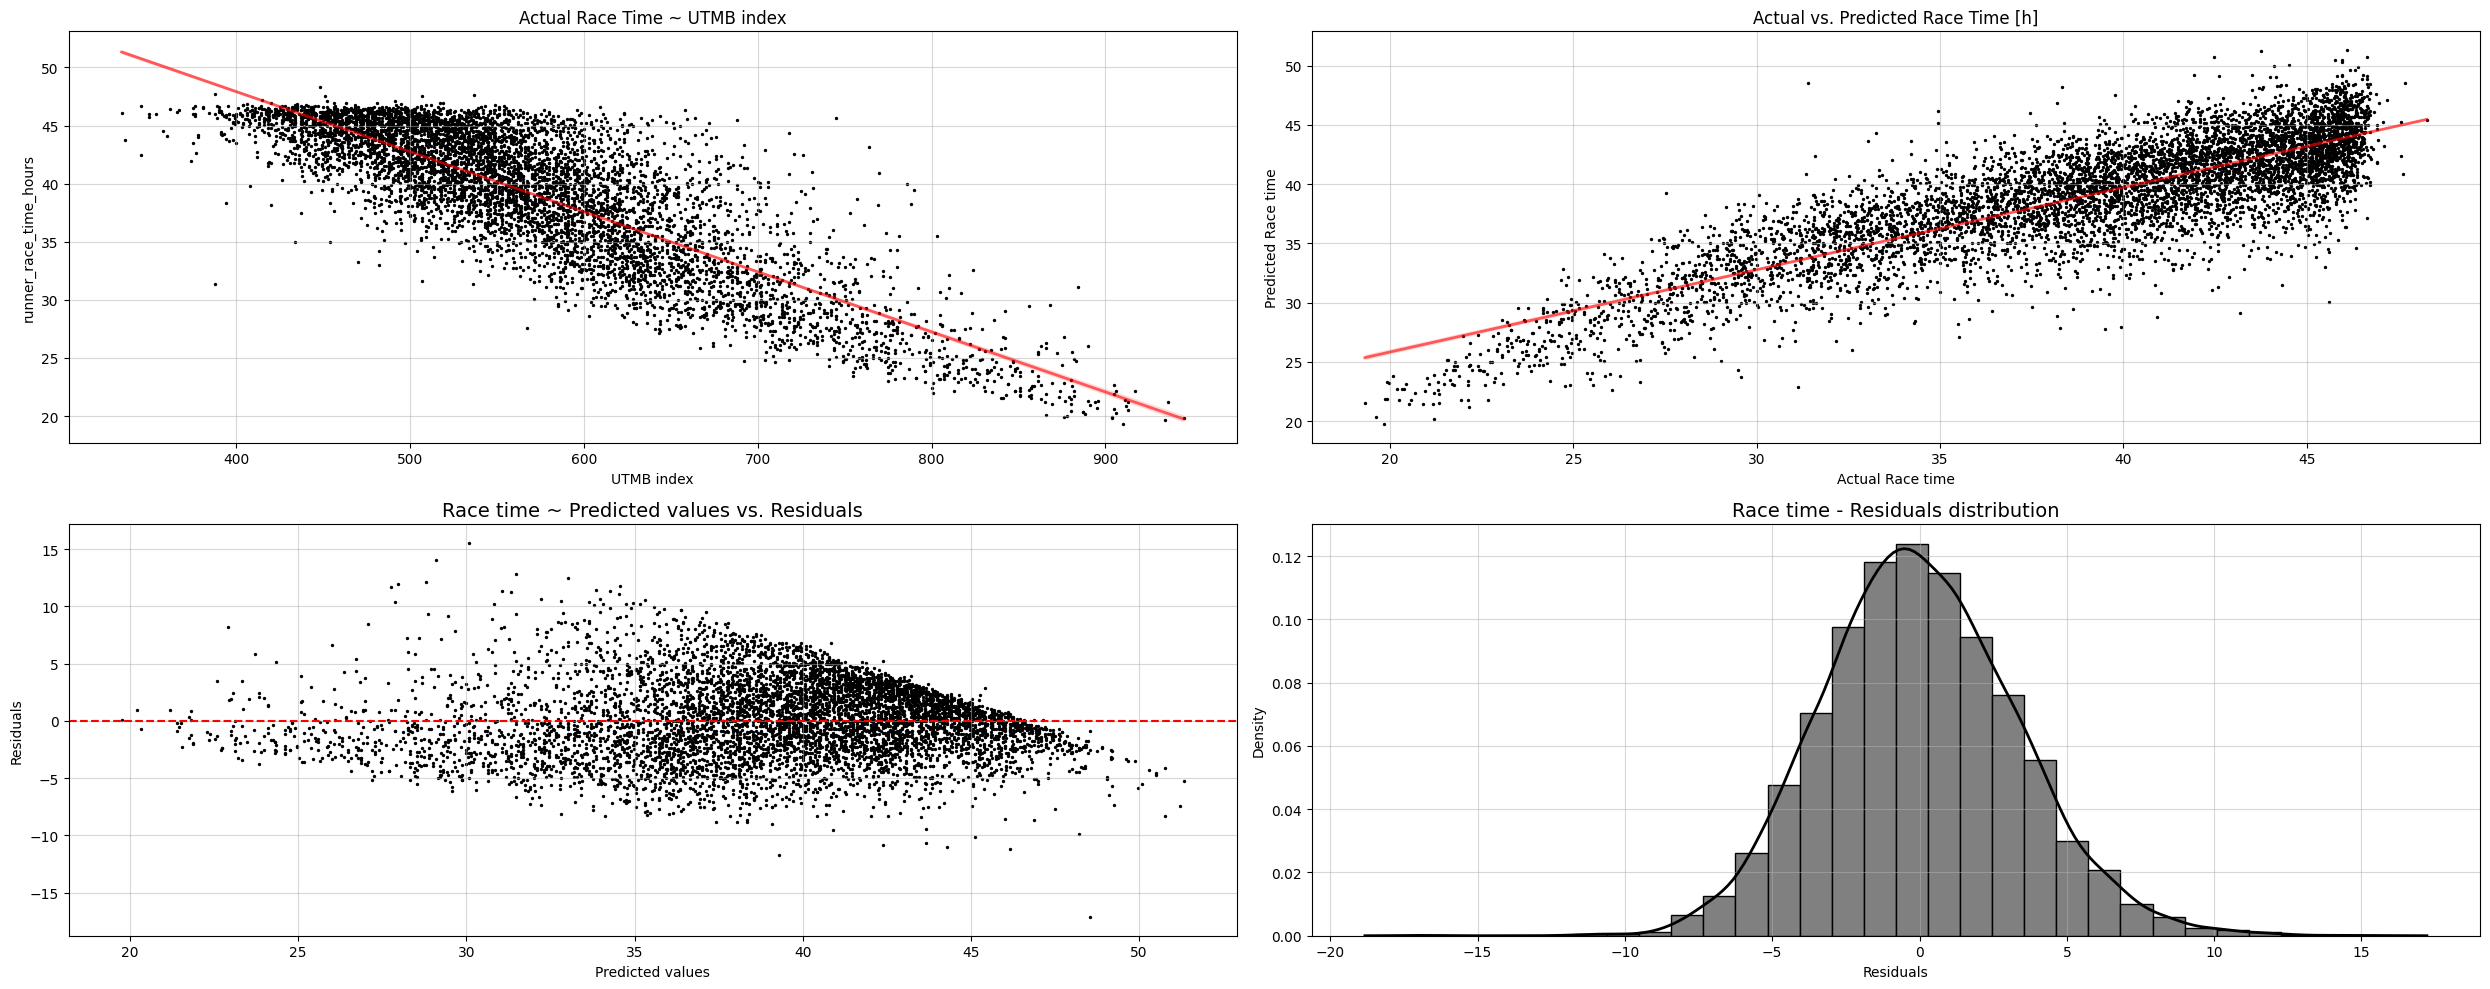

In [ ]:
# Model diagnostic

residuals_ols = y_ols - y_pred_ols
fig, ax = plt.subplots(2,2, figsize=(25,10))

# Actual Race Time ~ UTMB index
ax[0,0].set_title("Actual Race Time ~ UTMB index")
ax[0,0].scatter(data_model_ols["runner_overall_index"], data_model_ols["runner_race_time_hours"], color="black", s=2)
sns.regplot(x=data_model_ols["runner_overall_index"], y=data_model_ols["runner_race_time_hours"], scatter=False, color="red", line_kws={"linewidth": 2, "alpha": .6}, ax=ax[0,0])
ax[0,0].set_xlabel("UTMB index")

# Actual vs. Predicted Race time
ax[0,1].set_title("Actual vs. Predicted Race Time [h]")
ax[0,1].scatter(y_ols, y_pred_ols, color="black", s=2)
sns.regplot(x=y_ols, y=y_pred_ols, scatter=False, color="red", line_kws={"linewidth": 2, "alpha": .6}, ax=ax[0,1])
ax[0,1].set_xlabel("Actual Race time")
ax[0,1].set_ylabel("Predicted Race time")

# Residuals Homoskedasticity
ax[1,0].set_title("Race time ~ Predicted values vs. Residuals", fontsize=14)
ax[1,0].scatter(y_pred_ols, residuals_ols, color="black", s=2)
ax[1,0].axhline(0, color="red", linestyle="--")
ax[1,0].set_xlabel(f"Predicted values")
ax[1,0].set_ylabel("Residuals")

# Residuals KDE ~ Normality assumption
ax[1,1].set_title("Race time - Residuals distribution", fontsize=14)
ax[1,1].hist(residuals_ols, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(residuals_ols, ax=ax[1,1], color="black", linewidth=2)
ax[1,1].set_xlabel("Residuals")
ax[1,1].set_ylabel("Density")

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(alpha=.5)

plt.tight_layout()
plt.show()

---
### Goal: Probability of finishing under 27h ~ UTMB index

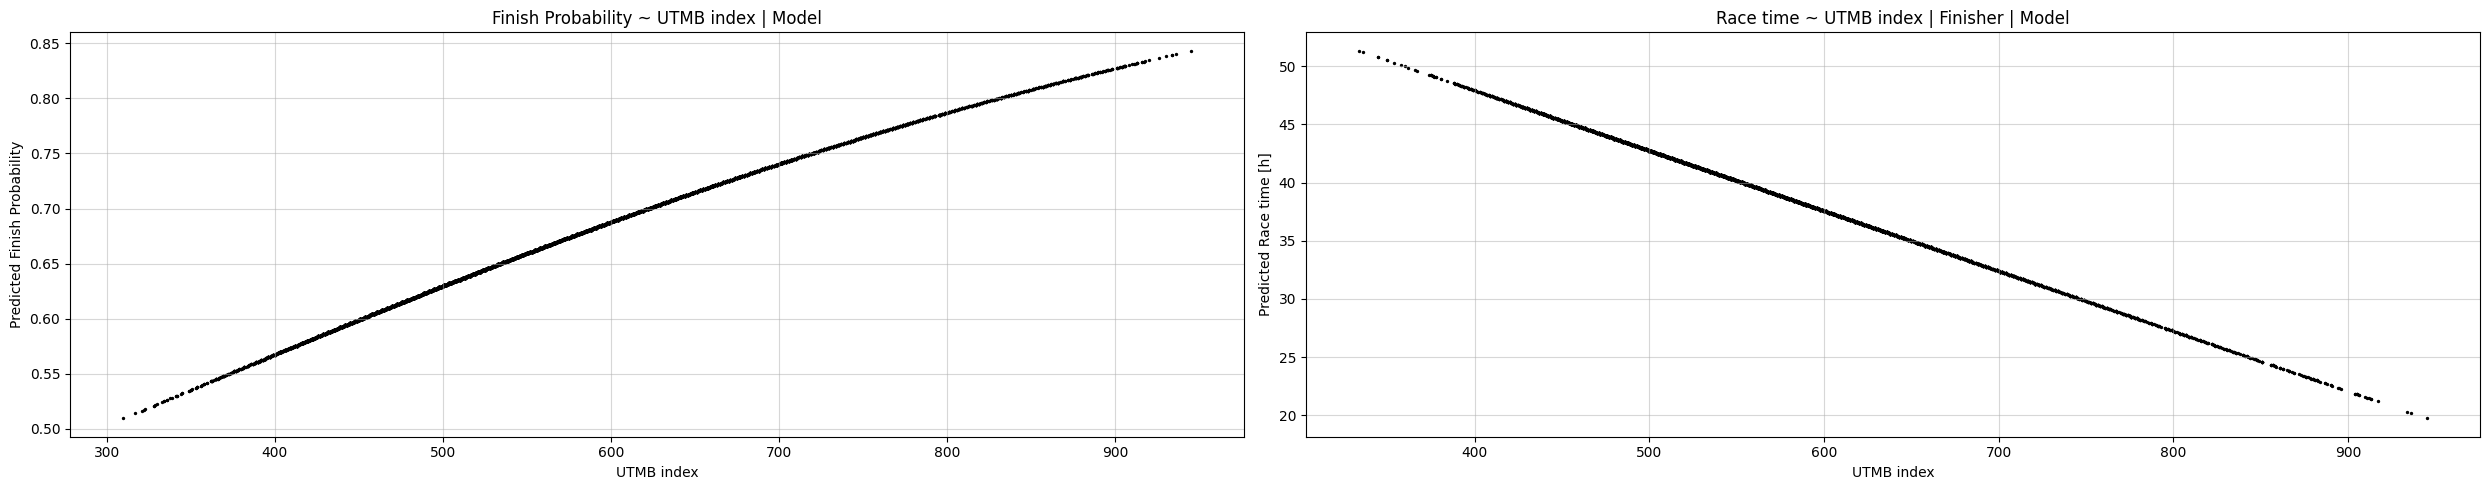

In [ ]:
# How does Finish probability and Race time behave on UTMB index - Based on models
fig, ax = plt.subplots(1,2, figsize=(25,5))

# Predicted Finish probability ~ UTMB index
ax[0].set_title("Finish Probability ~ UTMB index | Model")
ax[0].scatter(
    x=data_model_logit["runner_overall_index"], y=y_pred_logit,
    color="black", s=2
)
ax[0].set_ylabel("Predicted Finish Probability")

# Predicted Race time ~ UTMB index | Finisher
ax[1].set_title("Race time ~ UTMB index | Finisher | Model")
ax[1].scatter(
    x=data_model_ols["runner_overall_index"], y=y_pred_ols,
    color="black", s=2
)
ax[1].set_ylabel("Predicted Race time [h]")

for i in [0,1]:
    ax[i].set_xlabel("UTMB index")
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [152]:
# P(X <= x) = CDF((x - mu(x)) / sigma); X ~ N(mu(x), sigma^2), x = Grid of UTMB indices, X = Race time
sigma_ols = fit_ols.resid.std(ddof=2)
utmb_index_grid = np.arange(300, 1001, 1)
finish_prob = fit_logit.predict(sm.add_constant(utmb_index_grid))
race_time_mu = fit_ols.predict(sm.add_constant(utmb_index_grid))
race_time_under_prob = norm.cdf(27, loc=race_time_mu, scale=sigma_ols)

race_time_under_prob_df = pd.DataFrame({
    "runner_overall_index": utmb_index_grid,
    "finish_prob": finish_prob,
    "race_time_mu": race_time_mu,
    "race_time_under_prob": race_time_under_prob
})

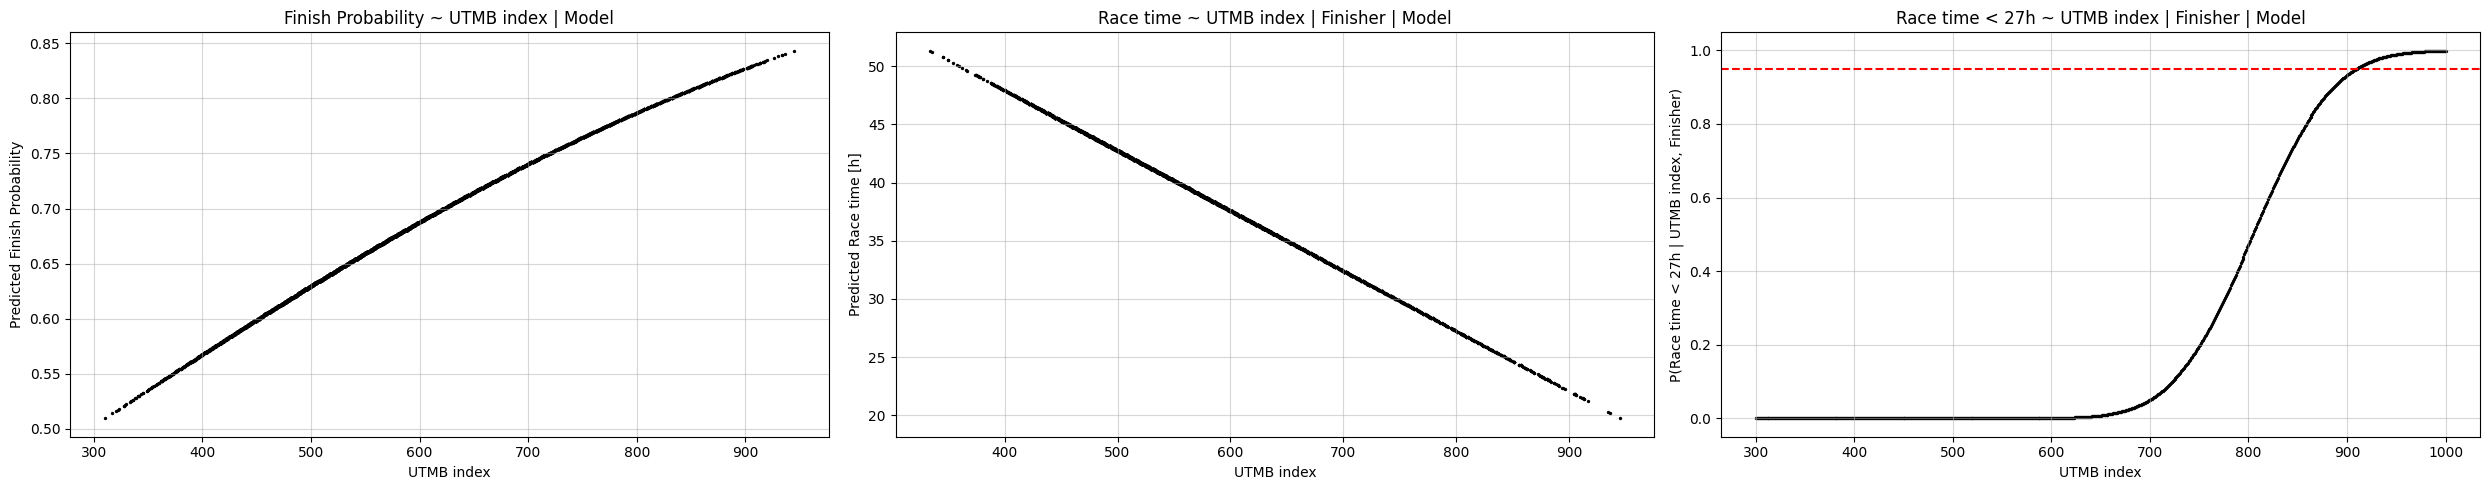

In [ ]:
# How does Finish probability and Race time behave on UTMB index - Based on models
fig, ax = plt.subplots(1,3, figsize=(25,5))

# Predicted Finish probability ~ UTMB index
ax[0].set_title("Finish Probability ~ UTMB index | Model")
ax[0].scatter(
    x=data_model_logit["runner_overall_index"], y=y_pred_logit,
    color="black", s=2
)
ax[0].set_ylabel("Predicted Finish Probability")

# Predicted Race time ~ UTMB index | Finisher
ax[1].set_title("Race time ~ UTMB index | Finisher | Model")
ax[1].scatter(
    x=data_model_ols["runner_overall_index"], y=y_pred_ols,
    color="black", s=2
)
ax[1].set_ylabel("Predicted Race time [h]")

# Predicted probability of finishing under 27h ~ UTMB index
ax[2].set_title("Race time < 27h ~ UTMB index | Finisher | Model")
ax[2].scatter(
    x=race_time_under_prob_df["runner_overall_index"], y=race_time_under_prob_df["race_time_under_prob"],
    color="black", s=2
)
ax[2].set_ylabel("P(Race time < 27h | UTMB index, Finisher)")
ax[2].axhline(0.95, color="red", linestyle="--", label="95% probability", lw=1.5)
ax[2].axvline(910, color="green", linestyle="--", label="UTMB index = 910", lw=1.5)
ax[2].legend(loc="lower right")

for i in [0,1,2]:
    ax[i].set_xlabel("UTMB index")
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [153]:
# Additional About - Calculated UTMB index
print("Insights from models for our goal of finishing under 27h:")
print("-------------------------------------------------------------------")

print("- Minimum UTMB index to have at least 95% probability of finishing under 27h: {:.0f}".format(
    race_time_under_prob_df.query("race_time_under_prob >= 0.95")["runner_overall_index"].min(),
))
print("- Probability of finishing the race for runner with UTMB index 910: {:.2f}%".format(
    race_time_under_prob_df.query("runner_overall_index == 910")["finish_prob"].iloc[0] * 100
))
print("- Predicted race time for runner with UTMB index 910: {:.2f} hours".format(
    race_time_under_prob_df.query("runner_overall_index == 910")["race_time_mu"].iloc[0]
))
print("- Variability of race time for runner with any UTMB index: {:.2f} hours".format(
    sigma_ols
))
print("- 95% confidence interval for predicted race time for runner with UTMB index 910: [{:.2f}, {:.2f}] hours".format(
    race_time_under_prob_df.query("runner_overall_index == 910")["race_time_mu"].iloc[0] - 1.96 * sigma_ols,
    race_time_under_prob_df.query("runner_overall_index == 910")["race_time_mu"].iloc[0] + 1.96 * sigma_ols
))

Insights from models for our goal of finishing under 27h:
-------------------------------------------------------------------
- Minimum UTMB index to have at least 95% probability of finishing under 27h: 910
- Probability of finishing the race for runner with UTMB index 910: 83.10%
- Predicted race time for runner with UTMB index 910: 21.56 hours
- Variability of race time for runner with any UTMB index: 3.30 hours
- 95% confidence interval for predicted race time for runner with UTMB index 910: [15.09, 28.02] hours


In [154]:
# Additional About - "Goal" UTMB index
print("Insights from models for our realistic goal UTMB index  780:")
print("-------------------------------------------------------------------")

print("- Probability of finishing under 27h for runner with UTMB index  780: {:.2f}%".format(
    race_time_under_prob_df.query("runner_overall_index == 780")["race_time_under_prob"].iloc[0] * 100
))
print("- Probability of finishing the race for runner with UTMB index 780: {:.2f}%".format(
    race_time_under_prob_df.query("runner_overall_index == 780")["finish_prob"].iloc[0] * 100
))
print("- Predicted race time for runner with UTMB index 780: {:.2f} hours".format(
    race_time_under_prob_df.query("runner_overall_index == 780")["race_time_mu"].iloc[0]
))
print("- Variability of race time for runner with any UTMB index: {:.2f} hours".format(
    sigma_ols
))
print("- 95% confidence interval for predicted race time for runner with UTMB index 780: [{:.2f}, {:.2f}] hours".format(
    race_time_under_prob_df.query("runner_overall_index == 780")["race_time_mu"].iloc[0] - 1.96 * sigma_ols,
    race_time_under_prob_df.query("runner_overall_index == 780")["race_time_mu"].iloc[0] + 1.96 * sigma_ols
))

Insights from models for our realistic goal UTMB index  780:
-------------------------------------------------------------------
- Probability of finishing under 27h for runner with UTMB index  780: 34.94%
- Probability of finishing the race for runner with UTMB index 780: 77.83%
- Predicted race time for runner with UTMB index 780: 28.28 hours
- Variability of race time for runner with any UTMB index: 3.30 hours
- 95% confidence interval for predicted race time for runner with UTMB index 780: [21.81, 34.74] hours
